<a href="https://colab.research.google.com/github/ParthJirapure/PBL_HACKO-WEEK/blob/main/Heart_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
uploaded = files.upload()

Saving heart.csv to heart (2).csv


In [32]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [33]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (303, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [34]:
print("First 5 Rows of Dataset:")
print(df.head())

First 5 Rows of Dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [35]:
print("Missing Values in Dataset:")
print(df.isnull().sum())

Missing Values in Dataset:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [36]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [37]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std   

In [38]:
print(df['target'].value_counts())

target
1    165
0    138
Name: count, dtype: int64


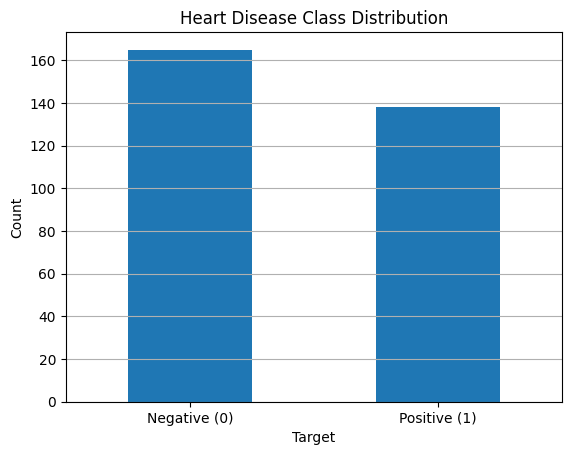

In [39]:
df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'], rotation=0)
plt.grid(axis='y')
plt.show()

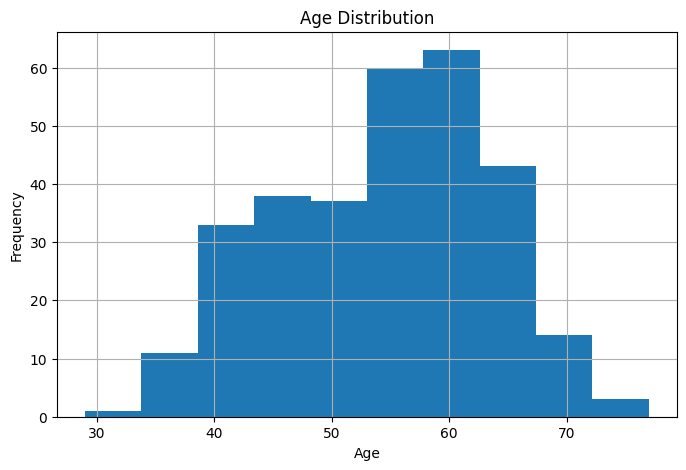

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

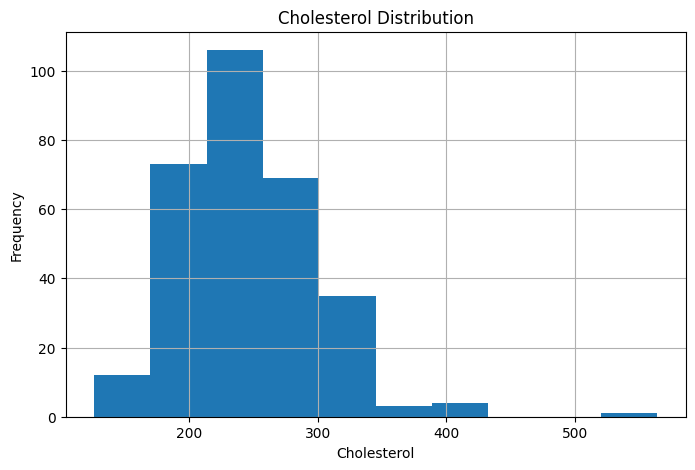

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df['chol'], bins=10)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

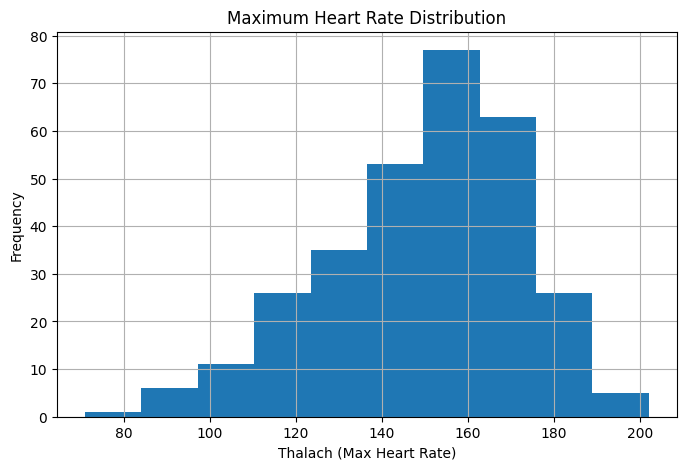

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df['thalach'], bins=10)
plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Thalach (Max Heart Rate)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

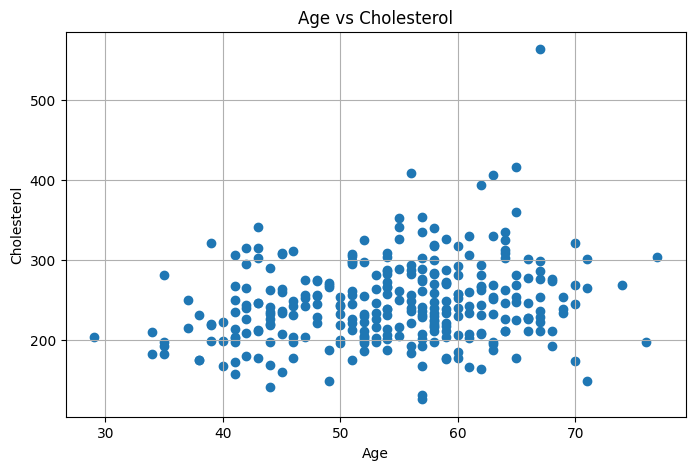

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['chol'])
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.grid(True)
plt.show()

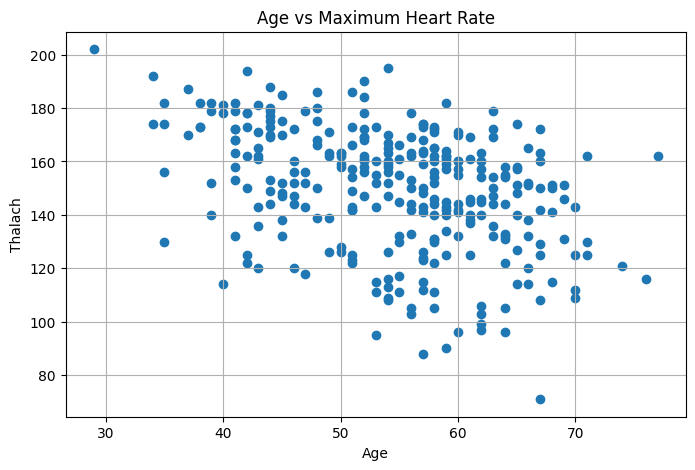

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['thalach'])
plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Thalach")
plt.grid(True)
plt.show()

In [45]:
X = df.drop('target', axis=1)
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (303, 13)
Target Shape: (303,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (242, 13)
Testing Data Shape: (61, 13)


In [47]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [48]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


In [49]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8688524590163934


In [50]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [51]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[25  4]
 [ 4 28]]


In [52]:
new_patient = pd.DataFrame({
    'age': [52],
    'sex': [1],
    'cp': [2],
    'trestbps': [130],
    'chol': [250],
    'fbs': [0],
    'restecg': [1],
    'thalach': [160],
    'exang': [0],
    'oldpeak': [1.2],
    'slope': [2],
    'ca': [0],
    'thal': [2]
})

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Prediction: Positive (Heart Disease Present)")
else:
    print("Prediction: Negative (No Heart Disease)")

Prediction: Positive (Heart Disease Present)


In [53]:
new_patients = pd.DataFrame({
    'age': [52, 60, 45],
    'sex': [1, 0, 1],
    'cp': [2, 3, 1],
    'trestbps': [130, 140, 120],
    'chol': [250, 290, 220],
    'fbs': [0, 1, 0],
    'restecg': [1, 0, 1],
    'thalach': [160, 130, 170],
    'exang': [0, 1, 0],
    'oldpeak': [1.2, 2.5, 0.8],
    'slope': [2, 1, 2],
    'ca': [0, 2, 0],
    'thal': [2, 3, 2]
})

predictions = model.predict(new_patients)
new_patients['Prediction'] = predictions
print(new_patients)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   2       130   250    0        1      160      0      1.2      2   
1   60    0   3       140   290    1        0      130      1      2.5      1   
2   45    1   1       120   220    0        1      170      0      0.8      2   

   ca  thal  Prediction  
0   0     2           1  
1   2     3           0  
2   0     2           1  


In [54]:
new_patients.to_csv("heart_predictions.csv", index=False)
print("Predictions saved successfully as heart_predictions.csv")

Predictions saved successfully as heart_predictions.csv


In [55]:
files.download("heart_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
print("PROJECT CONCLUSION")
print("-------------------")
print("1. Heart dataset was loaded successfully.")
print("2. Missing values and duplicate rows were checked.")
print("3. Dataset was visualized using graphs.")
print("4. Logistic Regression model was trained for prediction.")
print("5. The model predicts whether a person has heart disease or not.")

PROJECT CONCLUSION
-------------------
1. Heart dataset was loaded successfully.
2. Missing values and duplicate rows were checked.
3. Dataset was visualized using graphs.
4. Logistic Regression model was trained for prediction.
5. The model predicts whether a person has heart disease or not.
